# 1. Plot Cool vs Hot rec exemple (2023.11.09 - T1_H3)

### - Cool rec only

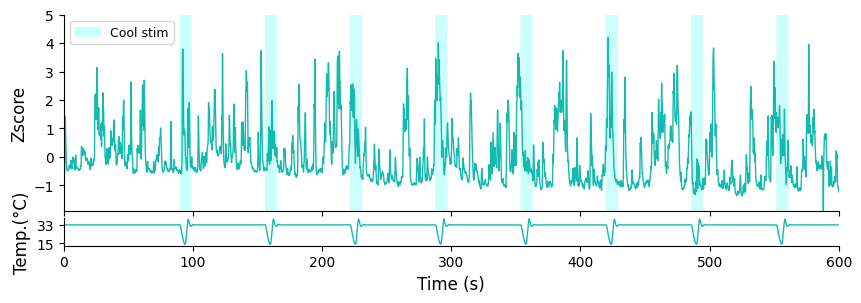

In [41]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter  # Importer la fonction savgol_filter
import pandas as pd

# 1. Chargement des données pour les deux DataFrames
df_cool = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_thermic_Zscore_classic_cool.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_cool = '2023.11.09'  # Remplacez par l'animal souhaité
rec_cool = 'Thermic_1'  # Remplacez par le rec souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_cool_filtered = df_cool[(df_cool['animal'] == animal_cool) & (df_cool['rec'] == rec_cool)].copy()

# Conversion du temps en secondes pour les deux DataFrames
df_cool_filtered.loc[:, 'time_sec'] = df_cool_filtered['time'] / 1000

# Appliquer un filtre de lissage (moyenne mobile) sur le Z-score et la température
window_length = 5  # Taille de la fenêtre (doit être impair)
polyorder = 3  # Ordre du polynôme

df_cool_filtered['Z-score_smoothed'] = savgol_filter(df_cool_filtered['Z-score'], window_length=window_length, polyorder=polyorder)


# 4. Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Premier Subplot : Z-score pour les deux conditions
sns.lineplot(x='time_sec', y='Z-score_smoothed', data=df_cool_filtered, ax=ax1, color='#13bbaf', linewidth=1) #label='Cool stim')

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore')
ax1.set_ylim(-1.9, 5)
ax1.set_xlim(0, 600)
# ax1.set_title('Zscore variation for cool and hot stim')

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#cafffb'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_cool_filtered[df_cool_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_thermic = row['time'] / 1000
    end_time_thermic = (row['time'] + 3900) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_thermic, end_time_thermic, color=thermic_color, zorder=0, label='Cool stim') #if i == 0 else "")

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Deuxième Subplot : Variation de la Température pour les deux DataFrames
sns.lineplot(x='time_sec', y='temperature', data=df_cool_filtered, ax=ax2, color='#13bbaf', linewidth=1)

# Ajuster les labels
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout

# Sauvegarder la figure en PNG
save_path = os.path.join(saving_dir, 'Zscore_rec_cool.png')
plt.savefig(save_path, format='png', dpi=300)

# Sauvegarder la figure en SVG
save_path = os.path.join(saving_dir, 'Zscore_rec_cool.svg')
plt.savefig(save_path, format='svg', dpi=300)

# Afficher le graphique
plt.show()


### - Hot rec only

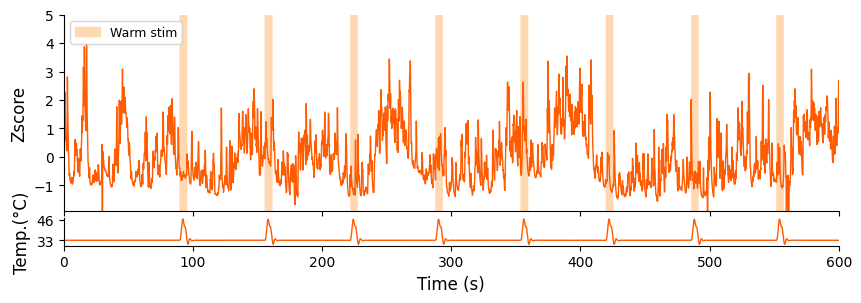

In [42]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter  # Importer la fonction savgol_filter
import pandas as pd

#1. Chargement des données pour les deux DataFrames
df_hot = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_hot_Zscore_classic_hot.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_hot = '2023.11.08'  # Remplacez par l'animal souhaité
rec_hot = 'hot_2'  # Remplacez par le rec souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_hot_filtered = df_hot[(df_hot['animal'] == animal_hot) & (df_hot['rec'] == rec_hot)].copy()

# Conversion du temps en secondes pour les deux DataFrames
df_hot_filtered.loc[:, 'time_sec'] = df_hot_filtered['time'] / 1000

# 4. Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Appliquer un filtre de lissage (moyenne mobile) sur le Z-score et la température
window_length = 5  # Taille de la fenêtre (doit être impair)
polyorder = 3  # Ordre du polynôme

df_hot_filtered['Z-score_smoothed'] = savgol_filter(df_hot_filtered['Z-score'], window_length=window_length, polyorder=polyorder)

# Premier Subplot : Z-score pour les deux conditions
sns.lineplot(x='time_sec', y='Z-score_smoothed', data=df_hot_filtered, ax=ax1, color='#ff5b00', linewidth=1) #label='Cool stim')

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore')
ax1.set_ylim(-1.9, 5)
ax1.set_xlim(0, 600)
# ax1.set_title('Zscore variation for cool and hot stim')

hot_color = '#ffd8b1'  # Couleur pour la période hot

# Périodes de stimulation chaudes
ts_periods_hot = df_hot_filtered[df_hot_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_hot.iterrows():
    start_time_hot = row['time'] / 1000
    end_time_hot = (row['time'] + 2200) / 1000  # Conversion en secondes (2.2s)
    ax1.axvspan(start_time_hot, end_time_hot, color=hot_color, zorder=1, label='Warm stim')

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')


# Deuxième Subplot : Variation de la Température pour les deux DataFrames
sns.lineplot(x='time_sec', y='temperature', data=df_hot_filtered, ax=ax2, color='#ff5b00', linewidth=1)

# Ajuster les labels
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Temp.(°C)')
ax2.set_yticks([33, 46])
ax2.set_yticklabels(['33', '46'])


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout

# Afficher le graphique
plt.show()


# 2. Plot PSTC

Valeur maximale de Znorm pour la condition Cool (entre 0 et 3.9 s) : 0.9337590788233481
Valeur maximale de Znorm pour la condition Warm (entre 0 et 3.9 s) : 0.4597494607247454


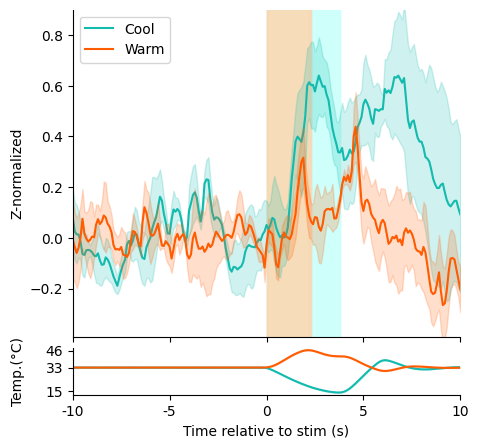

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Répertoires contenant les fichiers Excel
input_directory_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_cool_Trial_MeanSEM/'
input_directory_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_hot_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle pour les deux datasets
file_pattern_cool = os.path.join(input_directory_cool, 'Df_thermic_Zscore_classic_cool_*_trial_mean_SEM.xlsx')
file_pattern_hot = os.path.join(input_directory_hot, 'Df_hot_Zscore_classic_hot_*_trial_mean_SEM.xlsx')

files_1 = glob.glob(file_pattern_cool)
files_2 = glob.glob(file_pattern_hot)

# Charger et combiner les données de tous les fichiers pour les deux datasets
dfs_1 = []
for file_path in files_1:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_1.append(df)

dfs_2 = []
for file_path in files_2:
    df = pd.read_excel(file_path)
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')
    df['FileName'] = save_file_name
    dfs_2.append(df)

# Combiner les deux datasets
df_combined_1 = pd.concat(dfs_1, ignore_index=True)
df_combined_2 = pd.concat(dfs_2, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes pour les deux datasets
df_combined_1['time_sec'] = df_combined_1['Stim_Time'] / 1000
df_combined_2['time_sec'] = df_combined_2['Stim_Time'] / 1000

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'  # light light blue

# Calculer la moyenne et SEM pour le premier dataset
mean_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()
SEM_zscore_1 = df_combined_1.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Calculer la moyenne et SEM pour le second dataset
mean_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()
SEM_zscore_2 = df_combined_2.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Tracer la courbe moyenne et l'ombre de SEM pour le premier dataset (bleu)
ax1.plot(mean_zscore_1['time_sec'], mean_zscore_1['Mean_Zscore_norm'], color='#13bbaf', linewidth=1.5, linestyle='-', zorder=2, label='Cool')
ax1.fill_between(mean_zscore_1['time_sec'], 
                 mean_zscore_1['Mean_Zscore_norm'] - SEM_zscore_1['Mean_Zscore_norm'], 
                 mean_zscore_1['Mean_Zscore_norm'] + SEM_zscore_1['Mean_Zscore_norm'], 
                 color='#13bbaf', alpha=0.2, zorder=2,)

# Tracer la courbe moyenne et l'ombre de SEM pour le second dataset (orange)
ax1.plot(mean_zscore_2['time_sec'], mean_zscore_2['Mean_Zscore_norm'], color='#ff5b00', linewidth=1.5, linestyle='-', zorder=2, label='Warm')
ax1.fill_between(mean_zscore_2['time_sec'], 
                 mean_zscore_2['Mean_Zscore_norm'] - SEM_zscore_2['Mean_Zscore_norm'], 
                 mean_zscore_2['Mean_Zscore_norm'] + SEM_zscore_2['Mean_Zscore_norm'], 
                 color='#ff5b00', alpha=0.2, zorder=2)

# Ajouter la période TS en arrière-plan cool stim
in_ts_period = False
start_time = None
for i, row in df_combined_1.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        ax1.fill_between(df_combined_1['time_sec'], -1, 2, 
                         where=(df_combined_1['time_sec'] >= start_time) & (df_combined_1['time_sec'] <= end_time),
                         color=color_ts, alpha=0.2, zorder=0)
        in_ts_period = False


# Ajouter la période TS en arrière-plan hot stim
in_ts_period = False
start_time = None
for i, row in df_combined_2.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        ax1.fill_between(df_combined_2['time_sec'], -1, 2, 
                         where=(df_combined_2['time_sec'] >= start_time) & (df_combined_2['time_sec'] <= end_time),
                         color= '#ffd8b1', alpha=0.2, zorder=1)
        in_ts_period = False
    

# Tracer les données de température pour chaque dataset
sns.lineplot(data=df_combined_1, x='time_sec', y='Mean_temperature', color='#13bbaf', linewidth=1.5, ax=ax2)
sns.lineplot(data=df_combined_2, x='time_sec', y='Mean_temperature', color='#ff5b00', linewidth=1.5, ax=ax2)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized')
ax1.legend()
# ax1.set_title('Peristimulus curve for cool vs hot stimulation')

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad=15)
ax2.set_yticks([15, 33, 46])
ax2.set_yticklabels(['15', '33', '46'])
ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])


# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.39, 0.9)
ax1.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

# Ajouter les lignes pour trouver les valeurs maximales de Znorm entre 0 et 3.9 secondes
# Filtrer les données pour la condition Cool entre 0 et 3.9 secondes
condition_cool_filtered = df_combined_1[(df_combined_1['time_sec'] >= 0) & (df_combined_1['time_sec'] <= 3.9)]
max_zscore_cool = condition_cool_filtered['Mean_Zscore_norm'].max()

# Filtrer les données pour la condition Cool Urethane entre 0 et 3.9 secondes
condition_warm_filtered = df_combined_2[(df_combined_2['time_sec'] >= 0) & (df_combined_2['time_sec'] <= 3.9)]
max_zscore_warm = condition_warm_filtered['Mean_Zscore_norm'].max()

# Afficher les valeurs maximales
print(f"Valeur maximale de Znorm pour la condition Cool (entre 0 et 3.9 s) : {max_zscore_cool}")
print(f"Valeur maximale de Znorm pour la condition Warm (entre 0 et 3.9 s) : {max_zscore_warm}")


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout



# Afficher le graphique
plt.show()


# 3. Ploting AUC for cool vs hot

## N = animals

=== Résultats ===
Condition Period      Mean ± SEM  Sample Size (n) Shapiro Stat Shapiro p-value
     Cool     TB 0.2215 ± 0.0430                3       0.9914          0.8230
     Cool     TS 3.3326 ± 1.2660                3       0.7755          0.0572
     Cool    PTS 3.7800 ± 1.9839                3       0.7716          0.0483
      Hot     TB 0.2814 ± 0.1627                3       0.8580          0.2622
      Hot     TS 0.6030 ± 0.3722                3       0.9362          0.5125
      Hot    PTS 0.5348 ± 0.8006                3       0.7903          0.0915


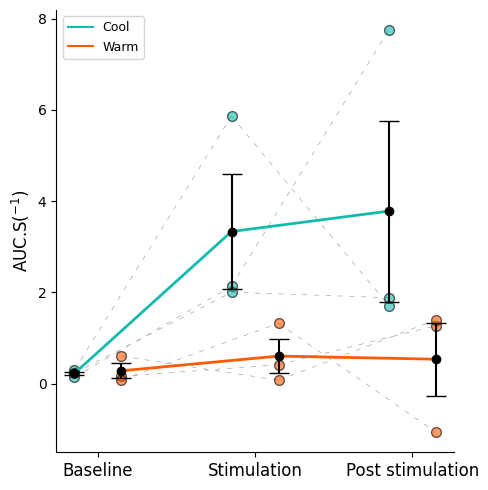

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import os
import matplotlib.lines as mlines


# Mise à jour des paramètres graphiques
plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,    # Taille des labels des axes
    'xtick.labelsize': 12,   # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,   # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9     # Taille de la police de la légende
})

# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_cool.xlsx'
file_path_auc_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_hot.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_hot = pd.read_excel(file_path_auc_hot)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_hot['Condition'] = 'Hot'

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_hot], ignore_index=True)

# Définir les périodes
periods = ['TB', 'TS', 'PTS']

# Préparer une structure pour stocker les résultats
results = []

# Itérer sur chaque condition et chaque période pour calculer les statistiques demandées
for condition in ['Cool', 'Hot']:
    for period in periods:
        # Filtrer les données pour la condition et la période
        data = df_combined[(df_combined['Condition'] == condition) & (df_combined['Period'] == period)]['AUC_Znorm_persec']
        
        # Calculer les statistiques
        mean_value = data.mean()
        sem_value = data.sem()
        sample_size = len(data)
        
        # Test de normalité Shapiro-Wilk
        shapiro_stat, shapiro_p = shapiro(data)
        
        # Ajouter les résultats dans une liste
        results.append({
            'Condition': condition,
            'Period': period,
            'Mean ± SEM': f"{mean_value:.4f} ± {sem_value:.4f}",
            'Sample Size (n)': sample_size,
            'Shapiro Stat': f"{shapiro_stat:.4f}",
            'Shapiro p-value': f"{shapiro_p:.4f}"
        })

# Convertir les résultats en DataFrame pour un affichage clair
df_results = pd.DataFrame(results)

# Afficher les résultats
print("=== Résultats ===")
print(df_results.to_string(index=False))


# Filtrer les données par période pour chaque variable
df_periods = {
    'Cool': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Cool')] for period in periods},
    'Hot': {period: df_combined[(df_combined['Period'] == period) & (df_combined['Condition'] == 'Hot')] for period in periods},
}


# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_cool': -0.15, 'AUC_Znorm_persec_hot': 0.15}
colors = {
    'AUC_Znorm_persec_cool': '#13bbaf',
    'AUC_Znorm_persec_hot': '#ff5b00'
}
border_colors = {key: 'black' for key in colors}



# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color, offset):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period] + offset] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=7, zorder=2)
    return means, sems



# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
means_hot, sems_hot = plot_variable(df_periods, 'Hot', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_hot'], border_colors['AUC_Znorm_persec_hot'], offsets['AUC_Znorm_persec_hot'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_cool'], label='Cool')
legend_line_ure = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_hot'], label='Warm')

# Ajouter la légende avec les couleurs personnalisées
plt.legend(handles=[legend_line_tactile, legend_line_ure], loc='upper left')


# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + offset, positions[periods[i + 1]] + offset
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
plot_connections(means_hot, 'AUC_Znorm_persec_hot', colors['AUC_Znorm_persec_hot'], offsets['AUC_Znorm_persec_hot'])



# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_combined, condition_name, variable_name, offset, color):
    # Filtrer par condition et par animal
    for animal in df_combined[df_combined['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_combined[(df_combined['Condition'] == condition_name) & (df_combined['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] + offset
            x2 = positions[periods[i + 1]] + offset
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_combined, 'Cool', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_cool'], colors['AUC_Znorm_persec_cool'])
plot_connections_per_animal(df_combined, 'Hot', 'AUC_Znorm_persec', offsets['AUC_Znorm_persec_hot'], colors['AUC_Znorm_persec_hot'])


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
# plt.grid(axis='y')


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 10,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout()


plt.show()


# N = trials -- Attention aux stat


--- COOL ---
TB : Mean ± SEM: 0.2215 ± 0.0706, n: 72
    Shapiro-Wilk : stat=0.9430, p-value=0.0027
TS : Mean ± SEM: 3.3326 ± 0.9870, n: 72
    Shapiro-Wilk : stat=0.9415, p-value=0.0023
PTS : Mean ± SEM: 3.7800 ± 1.0554, n: 72
    Shapiro-Wilk : stat=0.9761, p-value=0.1873

--- HOT ---
TB : Mean ± SEM: 0.2814 ± 0.0698, n: 72
    Shapiro-Wilk : stat=0.9268, p-value=0.0004
TS : Mean ± SEM: 0.6030 ± 0.8656, n: 72
    Shapiro-Wilk : stat=0.9653, p-value=0.0442
PTS : Mean ± SEM: 0.5348 ± 0.9007, n: 72
    Shapiro-Wilk : stat=0.9803, p-value=0.3191


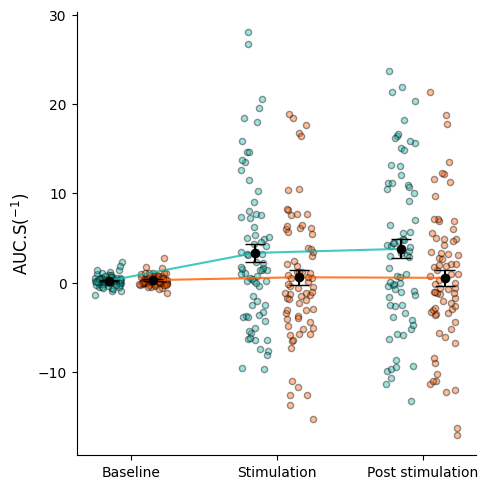

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import matplotlib.lines as mlines

# Chemins vers les fichiers Excel
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_cool.xlsx'
file_path_auc_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_hot.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_hot = pd.read_excel(file_path_auc_hot)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_hot['Condition'] = 'Hot'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')
df_auc_hot['Period_type'] = df_auc_hot['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul
df_combined = pd.concat([df_auc_cool, df_auc_hot], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']

df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Hot': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Hot')] for Period in Periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
offsets = {'AUC_Znorm_persec_cool': -0.15, 'AUC_Znorm_persec_hot': 0.15}
colors = {
    'AUC_Znorm_persec_cool': '#13bbaf',
    'AUC_Znorm_persec_hot': '#ff5b00'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color, offset):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period] + offset] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period] + offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=7, zorder=2)
    return means, sems

# Fonction pour afficher les informations statistiques
def print_stats(df_Periods, condition_name, variable_name):
    print(f"\n--- {condition_name.upper()} ---")
    for Period in Periods:
        data = df_Periods[condition_name][Period][variable_name].dropna()
        mean = data.mean()
        sem = data.sem()
        n = len(data)
        stat, p_value = shapiro(data)
        print(f"{Period} : Mean ± SEM: {mean:.4f} ± {sem:.4f}, n: {n}")
        print(f"    Shapiro-Wilk : stat={stat:.4f}, p-value={p_value:.4f}")

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_cool, sems_cool = plot_variable(df_Periods, 'Cool', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_cool'], border_colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
means_hot, sems_hot = plot_variable(df_Periods, 'Hot', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_hot'], border_colors['AUC_Znorm_persec_hot'], offsets['AUC_Znorm_persec_hot'])

# Afficher les statistiques pour chaque condition
print_stats(df_Periods, 'Cool', 'AUC_Znorm_persec')
print_stats(df_Periods, 'Hot', 'AUC_Znorm_persec')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color, offset):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]] + offset, positions[Periods[i + 1]] + offset
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

plot_connections(means_cool, 'AUC_Znorm_persec_cool', colors['AUC_Znorm_persec_cool'], offsets['AUC_Znorm_persec_cool'])
plot_connections(means_hot, 'AUC_Znorm_persec_hot', colors['AUC_Znorm_persec_hot'], offsets['AUC_Znorm_persec_hot'])

# Mise en forme du graphique
plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stimulation', 'Post stimulation'])
plt.ylabel(r'AUC.S($^{-1}$)')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


#### Fichier merged Cool-Warm AUC.s-1 for R stat

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_cool.xlsx'
file_path_auc_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_by_Period_hot.xlsx'

# Charger les données
df_auc_cool = pd.read_excel(file_path_auc_cool)
df_auc_ure = pd.read_excel(file_path_auc_hot)

# Ajouter une colonne pour identifier la condition
df_auc_cool['Condition'] = 'Cool'
df_auc_ure['Condition'] = 'Warm'

# Extraire le type de période (TB, TS, PTS)
df_auc_cool['Period_type'] = df_auc_cool['Period'].str.extract(r'([A-Za-z]+)')
df_auc_ure['Period_type'] = df_auc_ure['Period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_auc_cool, df_auc_ure], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Warm']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Warm': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Warm')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_Combined_cool_warm.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Quantif_by_Periods/AUC_persec_Znorm_Combined_cool_warm.xlsx


# 4. Response rate by condition

### 4.1. with N = animals

Cool condition: Mean = 50.00 ± SEM = 4.17
Warm condition: Mean = 22.22 ± SEM = 5.01

Résultats des tests de normalité (Shapiro-Wilk) :
Cool: Statistique = 0.7500, p-value = 0.0000
Warm: Statistique = 0.9231, p-value = 0.4633

Les données ne sont pas normalement distribuées. On procède au test de Wilcoxon.

Résultats du test de Wilcoxon :
Statistique : 0.0000
p-value : 0.2500

Taille des échantillons :
Cool : 3
Hot : 3


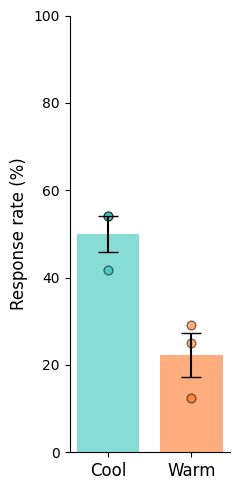

In [4]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Chemins des fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_cool.xlsx'
file_path_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(file_path_cool)
df_hot = pd.read_excel(file_path_hot)

# Calcul du taux de réponse moyen par animal pour chaque condition
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # En pourcentage

response_data_hot = df_hot.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_hot['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_cool['condition'] = 'Cool'
response_data_hot['condition'] = 'Warm'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_cool, response_data_hot])

# Calculer la moyenne du taux de réponse par animal pour chaque condition
mean_response_per_animal = combined_data.groupby(['animal', 'condition'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque condition
mean_response_data = mean_response_per_animal.groupby('condition').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque condition
for condition in mean_response_data['condition']:
    mean_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0]
    print(f"{condition} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque condition
mean_response_cool = mean_response_per_animal[mean_response_per_animal['condition'] == 'Cool']['response_rate']
mean_response_hot = mean_response_per_animal[mean_response_per_animal['condition'] == 'Warm']['response_rate']

normality_results = {
    "Cool": stats.shapiro(mean_response_cool),
    "Warm": stats.shapiro(mean_response_hot)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# Déterminer quel test utiliser
if all(result[1] >= 0.05 for result in normality_results.values()):
    # Test t de Student (normalité respectée)
    print("\nLes données sont normalement distribuées. On procède au test t de Student.")
    t_test_results = stats.ttest_ind(mean_response_cool, mean_response_hot)
    print("\nRésultats du test t de Student :")
    print(f"Statistique : {t_test_results.statistic:.4f}")
    print(f"p-value : {t_test_results.pvalue:.4f}")
    p_value = t_test_results.pvalue
else:
    # Test de Wilcoxon (normalité non respectée)
    print("\nLes données ne sont pas normalement distribuées. On procède au test de Wilcoxon.")
    wilcoxon_results = stats.wilcoxon(mean_response_cool, mean_response_hot)
    print("\nRésultats du test de Wilcoxon :")
    print(f"Statistique : {wilcoxon_results.statistic:.4f}")
    print(f"p-value : {wilcoxon_results.pvalue:.4f}")
    p_value = wilcoxon_results.pvalue

# Tracer les résultats
plt.figure(figsize=(2.5, 5))

# Barplot des taux de réponse moyens par condition avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour chaque condition
colors = ['#13bbaf', '#ff5b00']  # Cool (bleu) et Hot (orange)
for i, condition in enumerate(mean_response_data['condition']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0],
        label=f'{condition} Stim', color=colors[i], alpha = 0.5, capsize=7)

# Ajouter des points individuels pour chaque condition
for condition, color in zip(['Cool', 'Warm'], colors):
    individual_data = mean_response_per_animal[mean_response_per_animal['condition'] == condition]
    plt.scatter(
        [x[0] if condition == 'Cool' else x[1]] * len(individual_data),
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40  # Taille des points
    )

# Ajouter des barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black')

# Calculer les positions pour les barres de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10  # Ajuster la position pour la significativité
add_significance_bar(x[0], x[1], significance_y_position, p_value)

# Vérification des tailles d'échantillons
sample_size_cool = len(mean_response_cool)  # Taille de l'échantillon pour Cool
sample_size_hot = len(mean_response_hot)    # Taille de l'échantillon pour Hot

print("\nTaille des échantillons :")
print(f"Cool : {sample_size_cool}")
print(f"Hot : {sample_size_hot}")

# Mise en forme du graphique
# plt.title("response rate by animals")
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])
plt.ylim(0, 100)
# plt.grid(axis='y', linestyle='--', alpha=0.7)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})


# Affichage du graphique
plt.tight_layout()



plt.show()


### 4.2. with N = Trials (contengency)

Table de contingence :
Warm   0   1
Cool        
0     31   5
1     25  11

Résultat du test de McNemar :
Statistique : 5.0, p-value : 0.0003249142318964005


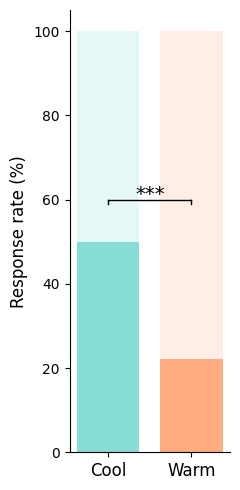

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar

# Chargement des données (déjà fait dans ton code précédent)
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_cool.xlsx'
file_path_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_hot.xlsx'

df_cool = pd.read_excel(file_path_cool)
df_hot = pd.read_excel(file_path_hot)

# Ajout de la colonne 'condition' pour différencier les groupes
df_cool['condition'] = 'Cool'
df_hot['condition'] = 'Warm'

# Combiner les données des deux conditions
combined_data = pd.concat([df_cool, df_hot])

# Comptage des réponses (0 ou 1) par condition
response_counts = combined_data.groupby(['condition', 'response_rate']).size().unstack(fill_value=0)

# Calcul des pourcentages de réponses 0 et 1 pour chaque condition
response_percentages = response_counts.div(response_counts.sum(axis=1), axis=0) * 100

# Création d'une table de contingence pour McNemar
# Comparaison des réponses 0 et 1 pour Cool et Hot
contingency_table = pd.crosstab(combined_data['response_rate'][combined_data['condition'] == 'Cool'],
                                combined_data['response_rate'][combined_data['condition'] == 'Warm'],
                                rownames=['Cool'], colnames=['Warm'])

# Test de McNemar
result = mcnemar(contingency_table, exact=True)

# Affichage des résultats du test de McNemar
print("Table de contingence :")
print(contingency_table)
print("\nRésultat du test de McNemar :")
print(f"Statistique : {result.statistic}, p-value : {result.pvalue}")

# Vérification de la significativité
if result.pvalue < 0.001:
    significance = "***"
elif result.pvalue < 0.01:
    significance = "**"
elif result.pvalue < 0.05:
    significance = "*"
else:
    significance = "ns"  # Pas significatif

# Création du graphique (bar chart avec les pourcentages)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Cool
ax.bar('Cool', response_percentages.loc['Cool', 1], color='#13bbaf', alpha=0.5, label='Réponse 1 (Cool)', width=0.75)

# Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Cool
ax.bar('Cool', response_percentages.loc['Cool', 0], color='#13bbaf', alpha=0.1, label='Réponse 0 (Cool)', width=0.75, bottom=response_percentages.loc['Cool', 1])

# Tracer la partie des barres correspondant à la réponse 1 (en couleur pleine et alpha = 0.5) pour Hot
ax.bar('Warm', response_percentages.loc['Warm', 1], color='#ff5b00', alpha=0.5, label='Réponse 1 (Warm)', width=0.75)

# Tracer la partie des barres correspondant à la réponse 0 (en couleur transparente et alpha = 0.1) pour Hot
ax.bar('Warm', response_percentages.loc['Warm', 0], color='#ff5b00', alpha=0.1, label='Réponse 0 (Warm)', width=0.75, bottom=response_percentages.loc['Warm', 1])


# Ajouter une barre de significativité si la différence est significative
if result.pvalue < 0.05:
    # Calculer la position de la barre
    y_bar = max(response_percentages.loc['Cool', 1], response_percentages.loc['Warm', 1]) + 10  # Position verticale

    # Tracer la barre horizontale
    ax.plot([0, 1], [y_bar, y_bar], color='black', lw=1)

    # Ajouter de petites barres verticales aux extrémités
    cap_height = 1  # Hauteur des petites barres
    ax.plot([0, 0], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à gauche
    ax.plot([1, 1], [y_bar - cap_height, y_bar], color='black', lw=1)  # Cap à droite


    # Ajouter les étoiles pour indiquer la significativité
    ax.text(0.5, max(response_percentages.loc['Cool', 1], response_percentages.loc['Warm', 1]) + 10,
            significance, ha='center', color='black', fontsize=14)

# Personnalisation du graphique
# ax.set_title('Response rate for cool vs hot condition')
ax.set_ylabel('Response rate (%)')
ax.set_xlabel('')
ax.set_xticks(['Cool', 'Warm'])
ax.set_xticklabels(['Cool', 'Warm'])

ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
fig.tight_layout()



plt.show()


### 4.3 with N = Trials


--- Résultats des tests de normalité (Shapiro-Wilk) ---
Cool: Statistique = 0.6365, p-value = 0.0000
Warm: Statistique = 0.5131, p-value = 0.0000

--- Résultats du test de Wilcoxon ---
Statistique : 77.5000
p-value : 0.0003

--- Résumé statistique pour chaque condition ---
Cool: Mean ± SEM = 50.0000 ± 5.9339, n = 72
Warm: Mean ± SEM = 22.2222 ± 4.9339, n = 72


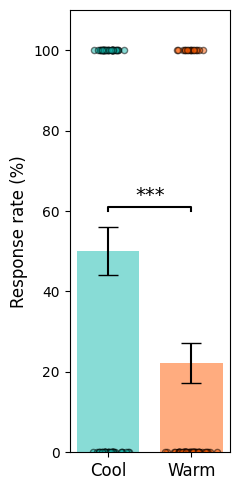

In [13]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np 

# Chemins des fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_cool.xlsx'
file_path_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_responsive_rate_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(file_path_cool)
df_hot = pd.read_excel(file_path_hot)

# Calcul du taux de réponse moyen par trial pour chaque condition
response_data_cool = df_cool.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_cool['response_rate'] *= 100  # En pourcentage

response_data_hot = df_hot.groupby(['animal', 'rec', 'trial'])['response_rate'].mean().reset_index()
response_data_hot['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'condition' pour différencier les groupes
response_data_cool['condition'] = 'Cool'
response_data_hot['condition'] = 'Warm'

# Combiner les données des deux conditions
combined_data = pd.concat([response_data_cool, response_data_hot])

# Vérification de la normalité (Shapiro-Wilk) pour chaque condition
mean_response_cool = response_data_cool['response_rate']
mean_response_hot = response_data_hot['response_rate']

normality_results = {
    "Cool": stats.shapiro(mean_response_cool),
    "Warm": stats.shapiro(mean_response_hot)
}

print("\n--- Résultats des tests de normalité (Shapiro-Wilk) ---")
for condition, result in normality_results.items():
    print(f"{condition}: Statistique = {result.statistic:.4f}, p-value = {result.pvalue:.4f}")

# Choisir le test approprié en fonction des résultats de normalité
if all(result.pvalue > 0.05 for result in normality_results.values()):
    # Si les deux distributions sont normales, on utilise le test t de Student apparié
    test_name = "test t de Student apparié"
    test_results = stats.ttest_rel(mean_response_cool, mean_response_hot)
else:
    # Sinon, on utilise le test de Wilcoxon
    test_name = "test de Wilcoxon"
    test_results = stats.wilcoxon(mean_response_cool, mean_response_hot)

# Affichage des résultats du test statistique approprié
print(f"\n--- Résultats du {test_name} ---")
print(f"Statistique : {test_results.statistic:.4f}")
print(f"p-value : {test_results.pvalue:.4f}")

# Calcul des moyennes, SEM et taille d'échantillon pour chaque condition
mean_response_data = combined_data.groupby('condition').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', stats.sem),
    sample_size=('response_rate', 'size')
).reset_index()

print("\n--- Résumé statistique pour chaque condition ---")
for _, row in mean_response_data.iterrows():
    print(f"{row['condition']}: Mean ± SEM = {row['mean_response']:.4f} ± {row['sem_response']:.4f}, n = {row['sample_size']}")

# Tracer les résultats
plt.figure(figsize=(2.5, 5))
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(mean_response_data['condition']))

# Barres pour les conditions
colors = ['#13bbaf', '#ff5b00']  # Couleurs pour Cool et Hot
for idx, (condition, color) in enumerate(zip(mean_response_data['condition'], colors)):
    mean = mean_response_data.loc[mean_response_data['condition'] == condition, 'mean_response'].values[0]
    sem = mean_response_data.loc[mean_response_data['condition'] == condition, 'sem_response'].values[0]
    plt.bar(
        idx,
        mean,
        width=bar_width,
        yerr=sem,
        label=f'{condition} Stim',
        color=color,
        alpha=0.5,
        capsize=7
    )

# Ajouter des points individuels avec jitter
for condition, color, x_coord in zip(['Cool', 'Warm'], colors, x):
    individual_data = combined_data[combined_data['condition'] == condition]
    jitter = np.random.normal(0, 0.1, size=len(individual_data))  # Jitter aléatoire autour de x_coord
    plt.scatter(
        x_coord + jitter,
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=20
    )

# Fonction pour ajouter des barres de significativité
def add_significance_bar(x1, x2, y, p_val, height_offset=1, fontsize=14):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1.5, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Ajouter la barre de significativité
significance_y_position = max(mean_response_data['mean_response']) + 10
add_significance_bar(x[0], x[1], significance_y_position, test_results.pvalue)

plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['condition'])  # Les xticks sont maintenant centrés
plt.ylim(0, 110)

# Affichage du graphique
plt.tight_layout()
plt.show()


# 5. Above threshold rate

### 5.1. with n = animals

Mean ± SEM, n (Sample Size) for each condition and period:
Cool - TB: Mean = 2.7778 ± SEM = 0.3545, n = 72
Cool - TS: Mean = 12.0466 ± SEM = 2.5296, n = 72
Cool - PTS: Mean = 13.5759 ± SEM = 2.3536, n = 72
Hot - TB: Mean = 1.9028 ± SEM = 0.3141, n = 72
Hot - TS: Mean = 4.6077 ± SEM = 1.4026, n = 72
Hot - PTS: Mean = 6.1534 ± SEM = 1.4321, n = 72

Shapiro-Wilk Normality Test (statistic, p-value):
Cool - TB: statistic = 0.8487, p-value = 0.0000
Cool - TS: statistic = 0.6325, p-value = 0.0000
Cool - PTS: statistic = 0.7227, p-value = 0.0000
Hot - TB: statistic = 0.7137, p-value = 0.0000
Hot - TS: statistic = 0.4493, p-value = 0.0000
Hot - PTS: statistic = 0.5681, p-value = 0.0000


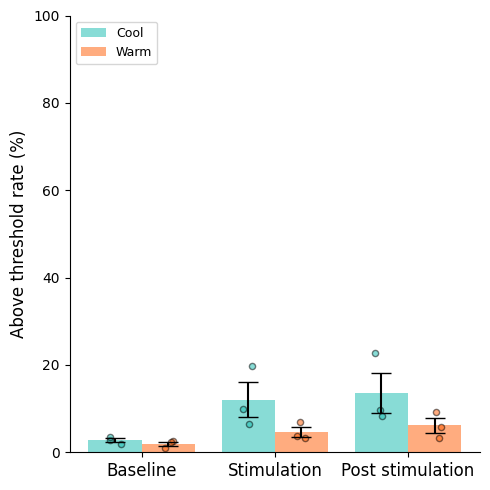

In [26]:

import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_Norm_response_rate_cool.xlsx'
hot_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_Norm_response_rate_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_hot = pd.read_excel(hot_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_hot], ['Cool', 'Hot']):
    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]
        if not all(period_data['count'] == 24):
            print(f"Problème avec la période {period}: Il n'y a pas exactement 24 observations par animal.")

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()
mean_hot_animal = df_hot.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_hot = mean_hot_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_hot = mean_hot_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_hot = mean_hot.set_index('period_type').reindex(period_order).reset_index()
sem_hot = sem_hot.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate'],
    'mean_response_hot': mean_hot['Norm_response_rate'],
    'sem_response_hot': sem_hot['Norm_response_rate']
})

# Afficher la moyenne ± SEM et la taille d'échantillon pour chaque condition et période
print("Mean ± SEM, n (Sample Size) for each condition and period:")
for condition, df in zip(['Cool', 'Hot'], [df_cool, df_hot]):
    for period in ['TB', 'TS', 'PTS']:
        period_data = df[df['period_type'] == period]['Norm_response_rate']
        mean_value = period_data.mean()
        sem_value = period_data.sem()
        sample_size = len(period_data)
        print(f"{condition} - {period}: Mean = {mean_value:.4f} ± SEM = {sem_value:.4f}, n = {sample_size}")

# Test de normalité de Shapiro-Wilk pour chaque période et condition
print("\nShapiro-Wilk Normality Test (statistic, p-value):")
for condition, df in zip(['Cool', 'Hot'], [df_cool, df_hot]):
    for period in ['TB', 'TS', 'PTS']:
        period_data = df[df['period_type'] == period]['Norm_response_rate']
        stat, p_value = stats.shapiro(period_data)
        print(f"{condition} - {period}: statistic = {stat:.4f}, p-value = {p_value:.4f}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition Hot
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_hot'],
        width=bar_width, yerr=mean_response_data['sem_response_hot'],
        label='Warm', color='#ff5b00', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['Norm_response_rate']
    hot_values = mean_hot_animal[mean_hot_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in hot_values],
                hot_values, color='#ff5b00', edgecolor='black', s=20, alpha=0.5)

# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()
plt.show()


### 5.2. with n = Trials


Test de normalité pour la période TB (Cool) : n = 72
Statistique = 0.8487, p-value = 0.0000
Moyenne = 2.7778 ± SEM = 0.3545

Test de normalité pour la période TB (Hot) : n = 72
Statistique = 0.7137, p-value = 0.0000
Moyenne = 1.9028 ± SEM = 0.3141

Test de normalité pour la période TS (Cool) : n = 72
Statistique = 0.6325, p-value = 0.0000
Moyenne = 12.0466 ± SEM = 2.5296

Test de normalité pour la période TS (Hot) : n = 72
Statistique = 0.4493, p-value = 0.0000
Moyenne = 4.6077 ± SEM = 1.4026

Test de normalité pour la période PTS (Cool) : n = 72
Statistique = 0.7227, p-value = 0.0000
Moyenne = 13.5759 ± SEM = 2.3536

Test de normalité pour la période PTS (Hot) : n = 72
Statistique = 0.5681, p-value = 0.0000
Moyenne = 6.1534 ± SEM = 1.4321


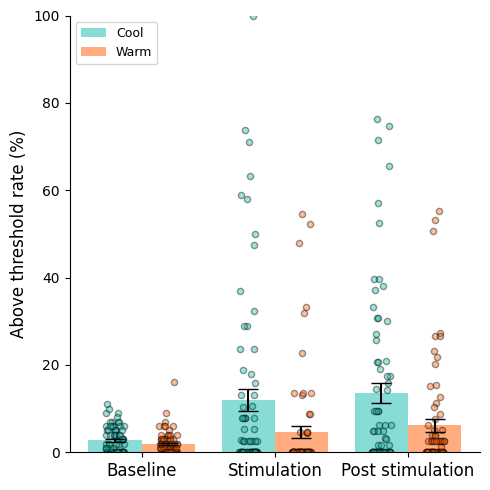

In [27]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_Norm_response_rate_cool.xlsx'
hot_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_shuffling_threshold/Shuffling_threshold_cool_vs_hot/Thq_Norm_response_rate_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_hot = pd.read_excel(hot_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_hot], ['Cool', 'Hot']):
    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')
    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]
        if not all(period_data['count'] == 24):
            print(f"Problème avec la période {period}: Il n'y a pas exactement 24 observations par animal.")

# Extraire le type de période (TS, TB, PTS)
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_filtered = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]
df_hot_filtered = df_hot[df_hot['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_cool = df_cool_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

mean_hot = df_hot_filtered.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_hot = df_hot_filtered.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_hot = mean_hot.set_index('period_type').reindex(period_order).reset_index()
sem_hot = sem_hot.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['Norm_response_rate'],
    'sem_response_cool': sem_cool['Norm_response_rate'],
    'mean_response_hot': mean_hot['Norm_response_rate'],
    'sem_response_hot': sem_hot['Norm_response_rate']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    for cond in ['Cool', 'Hot']:
        data_subset = df_cool_filtered if cond == 'Cool' else df_hot_filtered
        period_data = data_subset[data_subset['period_type'] == period]['Norm_response_rate']
        
        # Affichage du nombre d'observations (n)
        n = len(period_data)
        print(f"\nTest de normalité pour la période {period} ({cond}) : n = {n}")
        
        # Test de Shapiro
        stat, p_value = shapiro(period_data)
        normality_results[period][cond] = {'statistic': stat, 'p_value': p_value}
        
        # Affichage des résultats du test de normalité
        print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')
        
        # Affichage de la moyenne ± SEM
        mean_val = period_data.mean()
        sem_val = stats.sem(period_data)
        print(f"Moyenne = {mean_val:.4f} ± SEM = {sem_val:.4f}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition Hot
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_hot'],
        width=bar_width, yerr=mean_response_data['sem_response_hot'],
        label='Warm', color='#ff5b00', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['Norm_response_rate']
    hot_values = df_hot_filtered[df_hot_filtered['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.07  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in hot_values],
                hot_values, color='#ff5b00', edgecolor='black', s=20, alpha=0.4)

# Titres et légendes
plt.xlabel('')
# plt.title("Norm_response_rate by conditions (N = trials)")
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()
plt.show()


#### Fichier merged Cool-Warm above threshold for R stat

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Norm_response_rate_cool.xlsx'
hot_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Norm_response_rate_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_hot = pd.read_excel(hot_file_path)

# Ajouter une colonne pour identifier la condition
df_cool['Condition'] = 'Cool'
df_hot['Condition'] = 'Warm'

# Extraire le type de période (TB, TS, PTS)
df_cool['Period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['Period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_cool, df_hot], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Warm']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Warm': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Warm')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Above_Threshold_Combined_cool_warm.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Above_Threshold_Combined_cool_warm.xlsx


# 6. Magnitude of the response

### 6.1. N = animals 

Moyennes ± SEM (4 chiffres après la virgule) :
Baseline: Cool - Mean: 0.0670 ± SEM: 0.0100, Hot - Mean: 0.0477 ± SEM: 0.0135
Stimulation: Cool - Mean: 0.3257 ± SEM: 0.1129, Hot - Mean: 0.1185 ± SEM: 0.0340
Post stimulation: Cool - Mean: 0.3425 ± SEM: 0.1133, Hot - Mean: 0.1558 ± SEM: 0.0420

Test de normalité (Shapiro-Wilk) :

Période TB:
  Cool - Statistique de Shapiro: 0.9715, p-value: 0.6759
  Hot - Statistique de Shapiro: 0.7726, p-value: 0.0507

Période TS:
  Cool - Statistique de Shapiro: 0.9421, p-value: 0.5357
  Hot - Statistique de Shapiro: 0.8381, p-value: 0.2090

Période PTS:
  Cool - Statistique de Shapiro: 0.8482, p-value: 0.2356
  Hot - Statistique de Shapiro: 0.9998, p-value: 0.9762


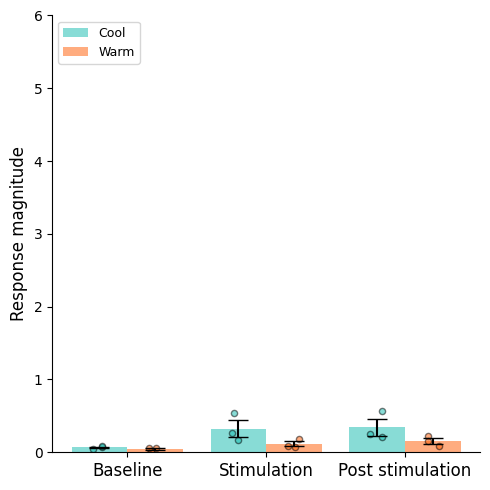

In [28]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_cool.xlsx'
hot_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_hot = pd.read_excel(hot_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_hot], ['Cool', 'Hot']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]
        if not all(period_data['count'] == 24):
            print(f"Problème avec la période {period}: Il n'y a pas exactement 24 observations par animal.")

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_cool_animal = df_cool.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()
mean_hot_animal = df_hot.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = mean_cool_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

mean_hot = mean_hot_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_hot = mean_hot_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_hot = mean_hot.set_index('period_type').reindex(period_order).reset_index()
sem_hot = sem_hot.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude'],
    'mean_response_hot': mean_hot['response_magnitude'],
    'sem_response_hot': sem_hot['response_magnitude']
})

# Afficher les résultats avec 4 chiffres après la virgule
print("Moyennes ± SEM (4 chiffres après la virgule) :")
for period, row in mean_response_data.iterrows():
    print(f"{row['period']}: Cool - Mean: {row['mean_response_cool']:.4f} ± SEM: {row['sem_response_cool']:.4f}, "
          f"Hot - Mean: {row['mean_response_hot']:.4f} ± SEM: {row['sem_response_hot']:.4f}")

# Ajouter le test de normalité de Shapiro-Wilk
print("\nTest de normalité (Shapiro-Wilk) :")
for period in ['TB', 'TS', 'PTS']:
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['response_magnitude']
    hot_values = mean_hot_animal[mean_hot_animal['period_type'] == period]['response_magnitude']
    
    # Test de normalité Shapiro-Wilk pour Cool et Hot
    stat_cool, p_value_cool = shapiro(cool_values)
    stat_hot, p_value_hot = shapiro(hot_values)
    
    print(f"\nPériode {period}:")
    print(f"  Cool - Statistique de Shapiro: {stat_cool:.4f}, p-value: {p_value_cool:.4f}")
    print(f"  Hot - Statistique de Shapiro: {stat_hot:.4f}, p-value: {p_value_hot:.4f}")

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition Hot
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_hot'],
        width=bar_width, yerr=mean_response_data['sem_response_hot'],
        label='Warm', color='#ff5b00', alpha=0.5, capsize=7)

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = mean_cool_animal[mean_cool_animal['period_type'] == period]['response_magnitude']
    hot_values = mean_hot_animal[mean_hot_animal['period_type'] == period]['response_magnitude']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.05  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.5)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in hot_values],
                hot_values, color='#ff5b00', edgecolor='black', s=20, alpha=0.5)

# Titres et légendes
plt.xlabel('')
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
plt.legend(loc='upper left')
plt.ylim(0, 6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()
plt.show()


### 6.2. N = Trials


Période: TB
Cool: Mean = 0.0670, SEM = 0.0087, n = 72
Hot: Mean = 0.0477, SEM = 0.0081, n = 72
Shapiro-Wilk Test (Cool): Stat = 0.8441, p-value = 0.0000
Shapiro-Wilk Test (Hot): Stat = 0.7157, p-value = 0.0000

Période: TS
Cool: Mean = 0.3257, SEM = 0.0711, n = 72
Hot: Mean = 0.1185, SEM = 0.0361, n = 72
Shapiro-Wilk Test (Cool): Stat = 0.6139, p-value = 0.0000
Shapiro-Wilk Test (Hot): Stat = 0.4520, p-value = 0.0000

Période: PTS
Cool: Mean = 0.3425, SEM = 0.0606, n = 72
Hot: Mean = 0.1558, SEM = 0.0383, n = 72
Shapiro-Wilk Test (Cool): Stat = 0.7191, p-value = 0.0000
Shapiro-Wilk Test (Hot): Stat = 0.5377, p-value = 0.0000


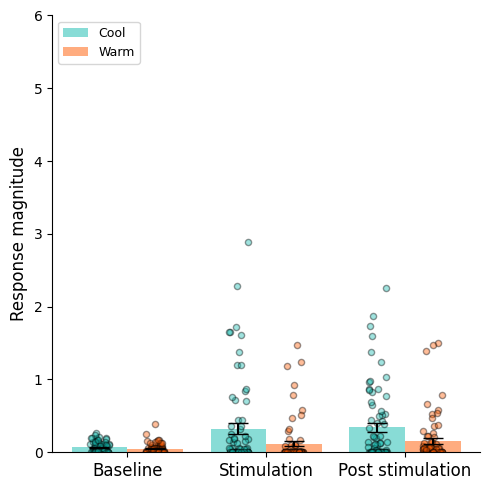

In [34]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, shapiro, friedmanchisquare

# Spécifier le chemin des fichiers Excel
cool_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_cool.xlsx'
hot_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_path)
df_hot = pd.read_excel(hot_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_cool, df_hot], ['Cool', 'Hot']):
    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')
    
    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]
        if not all(period_data['count'] == 24):
            print(f"Problème avec la période {period}: Il n'y a pas exactement 24 observations par animal.")

# Extraire le type de période (TS, TB, PTS)
df_cool['period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_cool_filtered = df_cool[df_cool['period_type'].isin(['TS', 'TB', 'PTS'])]
df_hot_filtered = df_hot[df_hot['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_cool = df_cool_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

mean_hot = df_hot_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_hot = df_hot_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_cool = mean_cool.set_index('period_type').reindex(period_order).reset_index()
sem_cool = sem_cool.set_index('period_type').reindex(period_order).reset_index()

mean_hot = mean_hot.set_index('period_type').reindex(period_order).reset_index()
sem_hot = sem_hot.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stimulation', 'Post stimulation'],
    'mean_response_cool': mean_cool['response_magnitude'],
    'sem_response_cool': sem_cool['response_magnitude'],
    'mean_response_hot': mean_hot['response_magnitude'],
    'sem_response_hot': sem_hot['response_magnitude']
})

# Print des résultats pour chaque période avec la mean ± SEM et n
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['response_magnitude']
    hot_values = df_hot_filtered[df_hot_filtered['period_type'] == period]['response_magnitude']
    
    # Calculer la moyenne et SEM pour chaque condition
    mean_cool = cool_values.mean()
    sem_cool = cool_values.sem()
    n_cool = len(cool_values)
    
    mean_hot = hot_values.mean()
    sem_hot = hot_values.sem()
    n_hot = len(hot_values)

    # Print des informations avec 4 chiffres après la virgule
    print(f"\nPériode: {period}")
    print(f"Cool: Mean = {mean_cool:.4f}, SEM = {sem_cool:.4f}, n = {n_cool}")
    print(f"Hot: Mean = {mean_hot:.4f}, SEM = {sem_hot:.4f}, n = {n_hot}")
    
    # Test de Shapiro-Wilk pour la normalité
    stat_cool, p_value_cool = shapiro(cool_values)
    stat_hot, p_value_hot = shapiro(hot_values)
    
    print(f"Shapiro-Wilk Test (Cool): Stat = {stat_cool:.4f}, p-value = {p_value_cool:.4f}")
    print(f"Shapiro-Wilk Test (Hot): Stat = {stat_hot:.4f}, p-value = {p_value_hot:.4f}")


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.4
x = range(len(mean_response_data['period']))

# Barres pour la condition Cool
plt.bar([p - bar_width/2 for p in x], mean_response_data['mean_response_cool'],
        width=bar_width, yerr=mean_response_data['sem_response_cool'],
        label='Cool', color='#13bbaf', alpha=0.5, capsize=7)

# Barres pour la condition Hot
plt.bar([p + bar_width/2 for p in x], mean_response_data['mean_response_hot'],
        width=bar_width, yerr=mean_response_data['sem_response_hot'],
        label='Warm', color='#ff5b00', alpha=0.5, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    cool_values = df_cool_filtered[df_cool_filtered['period_type'] == period]['response_magnitude']
    hot_values = df_hot_filtered[df_hot_filtered['period_type'] == period]['response_magnitude']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.07  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx - bar_width/2 + np.random.uniform(-jitter, jitter) for _ in cool_values],
                cool_values, color='#13bbaf', edgecolor='black', s=20, alpha=0.4)
    plt.scatter([period_idx + bar_width/2 + np.random.uniform(-jitter, jitter) for _ in hot_values],
                hot_values, color='#ff5b00', edgecolor='black', s=20, alpha=0.4)


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.ylim(0, 6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.titlesize': 12,   # Taille du titre des axes
    'axes.labelsize': 12,   # Taille des labels des axes
    'xtick.labelsize': 12,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 10,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9    # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

plt.show()


#### Fichier merged Cool-Warm response magnitude for R stat

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines


# Spécifier le chemin des fichiers Excel
cool_file_magnitude = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_cool.xlsx'
hot_file_magnitude = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Thq_Response_Magnitude_hot.xlsx'

# Lecture des fichiers Excel
df_cool = pd.read_excel(cool_file_magnitude)
df_hot = pd.read_excel(hot_file_magnitude)

# Ajouter une colonne pour identifier la condition
df_cool['Condition'] = 'Cool'
df_hot['Condition'] = 'Warm'

# Extraire le type de période (TB, TS, PTS)
df_cool['Period_type'] = df_cool['period'].str.extract(r'([A-Za-z]+)')
df_hot['Period_type'] = df_hot['period'].str.extract(r'([A-Za-z]+)')

# Fusionner les deux datasets en un seul pour simplifier la gestion
df_combined = pd.concat([df_cool, df_hot], ignore_index=True)

# Définir les périodes
Periods = ['TB', 'TS', 'PTS']
Conditions = ['Cool', 'Warm']

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Cool': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Cool')] for Period in Periods},
    'Warm': {Period: df_combined[(df_combined['Period_type'] == Period) & (df_combined['Condition'] == 'Warm')] for Period in Periods},
}

# Chemin pour le fichier Excel de sortie
output_file = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Resp_magnitude_Combined_cool_warm.xlsx'

# Sauvegarder le DataFrame dans un fichier Excel
df_combined.to_excel(output_file, index=False)

print(f"Le DataFrame df_combined a été sauvegardé dans le fichier : {output_file}")


Le DataFrame df_combined a été sauvegardé dans le fichier : G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Thresholding_cool_vs_hot/Resp_magnitude_Combined_cool_warm.xlsx


# Combo heatmap - PTSC

La valeur maximale de Znorm entre 0 et 3.9 secondes est : 5.432739781774175


C:\Users\zayan\AppData\Local\Temp\ipykernel_85652\783903573.py:85: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_85652\783903573.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


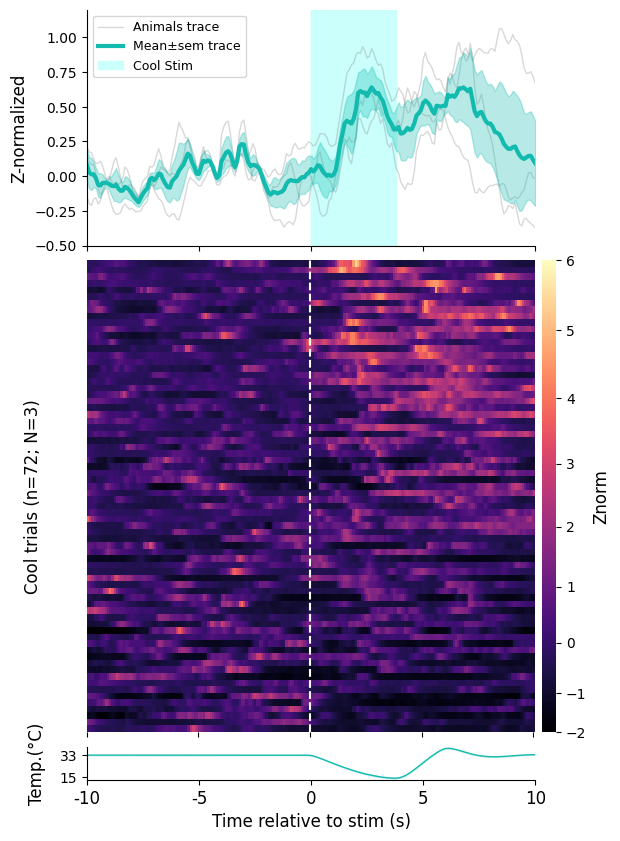

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_cool_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern_cool = os.path.join(input_directory_cool, 'Df_thermic_Zscore_classic_cool_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern_cool)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes



########################################################## HEATMAP #####################################################################

# Lire les fichiers Excel
file_path_cool = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_thermic_Zscore_classic_cool_stim.xlsx'
df_cool = pd.read_excel(file_path_cool)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_cool['Z-score_norm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_cool, 'Cool')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_cool['Stim_Time_sec'] = df_cool['Stim_Time'] / 1000


# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_cool[(df_cool['Stim_Time_sec'] >= 0) & (df_cool['Stim_Time_sec'] <= 3.9)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Z-score_norm'].max()

print("La valeur maximale de Znorm entre 0 et 3.9 secondes est :", max_znorm_value)


# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_cool_filtered = df_cool[(df_cool['Stim_Time_sec'] >= 0) & (df_cool['Stim_Time_sec'] <= 10)]
trial_sums = df_cool_filtered.groupby('Stim')['Z-score_norm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_cool['Stim'] = pd.Categorical(df_cool['Stim'], categories=trial_sums.index, ordered=True)
df_cool = df_cool.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_cool.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_cool[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Trouver l'index où les conditions 'Hot' commencent
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])

# Préparer les données pour la variation de température moyenne
temp_mean_cool = df_cool.groupby('Stim_Time_sec')['temperature'].mean()


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)
# gs = gridspec.GridSpec(nrows=3, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#cafffb'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Zscore_norm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Zscore_norm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Zscore_norm'] - SEM_zscore['Mean_Zscore_norm'], 
    mean_zscore['Mean_Zscore_norm'] + SEM_zscore['Mean_Zscore_norm'], 
    color='#13bbaf', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Zscore_norm'].min()
y_max = df_combined['Mean_Zscore_norm'].max()

# Ajuster les limites de l'axe y
ax0.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax0.get_ylim()[0] - y_min
y_max_diff = ax0.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 5 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Cool Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad=5)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 1.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Cool
num_cool_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Cool'])
ax1.text(-20, num_cool_trials / 2, f'Cool trials (n={num_cool_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')

###

################# Variation de température  #################

ax2 = plt.subplot(gs[2, 0])

sns.lineplot(
    data=df_combined, x='time_sec', y='Mean_temperature', 
    color='#13bbaf', linewidth=1, ax=ax2, # color = topaz
)

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)
ax2.set_yticks([15, 33])
ax2.set_yticklabels(['15', '33'])

# Enlever les bordures du haut et de droite
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

plt.show()

La valeur maximale de Znorm entre 0 et 3.9 secondes est : 4.723153924327152


C:\Users\zayan\AppData\Local\Temp\ipykernel_85652\4252684157.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined_hot = df_hot.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_85652\4252684157.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


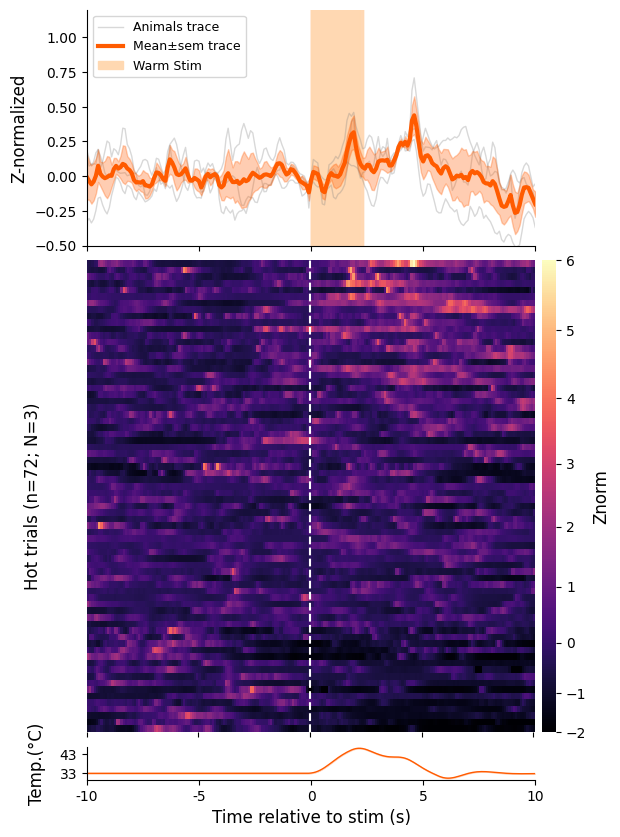

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_hot_Trial_MeanSEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern_hot = os.path.join(input_directory_hot, 'Df_hot_Zscore_classic_hot_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern_hot)

# Charger et combiner les données de tous les fichiers
dfs_hot = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs_hot.append(df)
df_combined_hot = pd.concat(dfs_hot, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined_hot['time_sec'] = df_combined_hot['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes



########################################################## HEATMAP #####################################################################

# Lire les fichiers Excel
file_path_hot = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_cool_vs_hot/Df_hot_Zscore_classic_hot_stim.xlsx'
df_hot = pd.read_excel(file_path_hot)

# # Trouver la valeur maximale de la colonne 'Znorm'
# max_znorm_value = df_hot['Z-score_norm'].max()
# print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'rec', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['rec'] == row['rec']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

# Appliquer aux deux DataFrames
add_stim_column(df_hot, 'Hot')

# Convertir Stim_Time en secondes dans les deux DataFrames
df_hot['Stim_Time_sec'] = df_hot['Stim_Time'] / 1000

# Filtrer les données pour les time_sec compris entre 0 et 3.9
df_filtered = df_hot[(df_hot['Stim_Time_sec'] >= 0) & (df_hot['Stim_Time_sec'] <= 3.9)]

# Trouver la valeur maximale de la colonne 'Z-score_norm' dans l'intervalle filtré
max_znorm_value = df_filtered['Z-score_norm'].max()

print("La valeur maximale de Znorm entre 0 et 3.9 secondes est :", max_znorm_value)

# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_hot_filtered = df_hot[(df_hot['Stim_Time_sec'] >= 0) & (df_hot['Stim_Time_sec'] <= 10)]
trial_sums = df_hot_filtered.groupby('Stim')['Z-score_norm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_hot['Stim'] = pd.Categorical(df_hot['Stim'], categories=trial_sums.index, ordered=True)
df_hot = df_hot.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined_hot = df_hot.pivot_table(index='Stim', columns='Stim_Time_sec', values='Z-score_norm', aggfunc='mean')
df_heatmap_combined_hot = df_heatmap_combined_hot.join(df_hot[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))

# Trouver l'index où les conditions 'Hot' commencent
num_hot_trials = len(df_heatmap_combined_hot[df_heatmap_combined_hot['Condition'] == 'Hot'])

# Préparer les données pour la variation de température moyenne
temp_mean_hot = df_hot.groupby('Stim_Time_sec')['temperature'].mean()


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)
# gs = gridspec.GridSpec(nrows=3, ncols=3, width_ratios=[10, 1, 0.1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#ffd8b1'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined_hot['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined_hot[df_combined_hot['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Zscore_norm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1,alpha=0.3, label='Animals trace')  # Légende unique


# Calculer la courbe moyenne des animaux
mean_zscore = df_combined_hot.groupby('time_sec')['Mean_Zscore_norm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Zscore_norm'], 
    color='#ff5b00', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined_hot.groupby('time_sec')['Mean_Zscore_norm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Zscore_norm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Zscore_norm'] - SEM_zscore['Mean_Zscore_norm'], 
    mean_zscore['Mean_Zscore_norm'] + SEM_zscore['Mean_Zscore_norm'], 
    color='#ff5b00', alpha=0.3, zorder=2, label=None
    )

# Calculer les limites réelles pour l'axe y
y_min = df_combined_hot['Mean_Zscore_norm'].min()
y_max = df_combined_hot['Mean_Zscore_norm'].max()

# Ajuster les limites de l'axe y
ax0.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Calculer la différence entre les limites y_graph et y_data
y_min_diff = ax0.get_ylim()[0] - y_min
y_max_diff = ax0.get_ylim()[1] - y_max

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined_hot.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined_hot['time_sec'], 
            y_min - 1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 5 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined_hot['time_sec'] >= start_time) & (df_combined_hot['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined_hot['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined_hot['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined_hot['time_sec'] >= start_time) & (df_combined_hot['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Warm Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad=5)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 1.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined_hot.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined_hot.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined_hot.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials hot
num_hot_trials = len(df_heatmap_combined_hot[df_heatmap_combined_hot['Condition'] == 'Hot'])
ax1.text(-20, num_hot_trials / 2, f'Hot trials (n={num_hot_trials}; N=3)', fontsize=12, color='black', va='center', ha='right', rotation='vertical')

###

################# Variation de température  #################

ax2 = plt.subplot(gs[2, 0])

sns.lineplot(
    data=df_combined_hot, x='time_sec', y='Mean_temperature', 
    color='#ff5b00', linewidth=1, ax=ax2, # color = topaz
)

ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Temp.(°C)', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_xlim(-10, 10)
ax2.set_yticks([33, 43])
ax2.set_yticklabels(['33', '43'])

# Enlever les bordures du haut et de droite
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

plt.show()